# Домашняя работа 7

В финальном домашнем задании необходимо ответить на вопрос, какой же алгоритм все таки лучше решает ту или иную задачу. А именно, нужно рассмотреть одну из следующих задач:

- CartPole
- Pendulum
- LunarLender с дискретным пространством действий (по умолчанию)
- LunarLender с непрерывным пространством действий (нужно положить continuous=True, см. пояснения здесь Lunar Lander)
- BipedalWalker

Нужно сравнить следующие алгоритмы:

- CEM со второй лекции. Для дискретного пространства действий CEM был реализован на практическом занятии 2, для непрерывного — был задан в рамках домашнего задания 2.
- DQN с Hard или Soft Target Networks с пятой лекции. Для дискретного пространства действий DQN был реализован на практическом занятии 5. Hard и Soft Target Networks было предложено реализовать в рамках домашнего задания 5. Кроме того, аналог Soft Target Networks был реализован на практическом занятии 7 в SAC. Для непрерывного пространства действий, его (пространство действий) следует дискретизировать. Например, если пространство действий - это отрезок [-2,2], то можно выбрать 3 действия {-2,0,2} или больше, например, 5 действий {-2,-1,0,1,2}. Если пространство действий квадрат [-1,1]^2, то — 5 действий {[-1,-1],[-1,1],[1,-1],[1,1],[0,0]} или больше. После такой дискретизации можно уже применять DQN.
- PPO с шестой лекции. Для непрерывного и скалярного пространства действий PPO был реализован на практическом занятии 6, для непрерывного многомерного и дискретного  — был задан в рамках домашнего задания 6.
- SAC с седьмой лекции. Для непрерывного и скалярного пространства действий SAC был реализован на практическом занятии 7, для непрерывного многомерного и дискретного  — предлагается реализовать в рамках текущего задания по аналогии с PPO.

Помимо выбранных алгоритмов разрешается (но не обязательно) проявить творческий подход и попробовать улучшить какой-либо из них каким-либо образом. При этом следует показать, что предложенная модификация действительно превосходит базовый вариант.

Сравнение алгоритмов корректно проводить согласно следующим принципам:

Понятно, что все алгоритмы имеют разный набор гиперпараметров. Тем не менее, сравнение разумного проводить выбирая одинаковые гиперпараметры в тех случая где они совпадают (например lr или batch_size).

Архитектуры NN также разумно выбирать одного размера.

В алгоритме CEM и PPO на одной итерации обучения генерируется несколько траекторий. Этот факт необходимо учитывать на графиках, либо выводя результаты total_reward для всех этих траекторий, либо беря усредненный total_reward по этим траекториям и растягивая его на графике на количество траекторий. Суть в том, чтобы корректно оценить скорость обучения алгоритмов относительно сгенерированных траекторий, а не относительно итераций.

Обязательным принципом при сравнении алгоритмов в исследованиях по RL является следующий. Необходимо запустить каждый алгоритм несколько раз (3,5,10 и т.д.) и на график выводить усредненную кривую обучения. Так мы учитываем эффект случайности в обучении обусловленный инициализацией NN, шумом при выборе действий и случайностью в среде.

Главным результатов этого задания должен стать график с усредненными (по запускам, см. выше) кривыми обучений всех алгоритмов, по x-оси которого количество сгенерированных траекторий, а по y-оси total_reward.

In [1]:
!pip install swig -q
!pip install gymnasium -q
!pip install gymnasium[box2d] -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import gymnasium as gym
import numpy as np
import random
from copy import deepcopy

import torch
import torch.nn as nn
from torch.distributions import Normal

import matplotlib.pyplot as plt
%matplotlib inline

## Environment

In [3]:
# env = gym.make('Pendulum-v1')
env = gym.make('LunarLander-v2', continuous=True)

print(env.observation_space)
print(env.action_space)

Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)
Box(-1.0, 1.0, (2,), float32)


In [4]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

print('state_dim =', state_dim)
print('action_dim =', action_dim)

state_dim = 8
action_dim = 2


In [5]:
action_low = env.action_space.low
action_high = env.action_space.high

## SAC Method

In [ ]:
class SAC(nn.Module):
    # Пространство действий непрерывное, многомерное

    def __init__(self, state_dim, action_dim, gamma=0.99, alpha=1e-3, tau=1e-2,
                 batch_size=64, pi_lr=1e-3, q_lr=1e-3):
        super().__init__()

        self.pi_model = nn.Sequential(nn.Linear(state_dim, 128),
                                      nn.ReLU(),
                                      nn.Linear(128, 128),
                                      nn.ReLU(),
                                      nn.Linear(128, 2 * action_dim),
                                      nn.Tanh())

        self.q1_model = nn.Sequential(nn.Linear(state_dim + action_dim, 128),
                                      nn.ReLU(),
                                      nn.Linear(128, 128),
                                      nn.ReLU(),
                                      nn.Linear(128, 1))

        self.q2_model = nn.Sequential(nn.Linear(state_dim + action_dim, 128),
                                      nn.ReLU(),
                                      nn.Linear(128, 128),
                                      nn.ReLU(),
                                      nn.Linear(128, 1))

        self.gamma = gamma
        self.alpha = alpha
        self.tau = tau
        self.batch_size = batch_size
        self.memory = []

        self.pi_optimizer = torch.optim.Adam(self.pi_model.parameters(), pi_lr)
        self.q1_optimizer = torch.optim.Adam(self.q1_model.parameters(), q_lr)
        self.q2_optimizer = torch.optim.Adam(self.q2_model.parameters(), q_lr)
        self.q1_target_model = deepcopy(self.q1_model)
        self.q2_target_model = deepcopy(self.q2_model)

    def get_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0)
        action, _ = self.predict_actions(state)
        return action.detach().numpy().reshape(action_dim)

    def fit(self, state, action, reward, termin, trunc, next_state):

        self.memory.append([state, action, reward, termin, trunc, next_state])

        if len(self.memory) > self.batch_size:
            batch = random.sample(self.memory, self.batch_size)
            states, actions, rewards, termins, truncs, next_states = map(
                                             np.array, zip(*batch))
            states, actions, rewards, termins, truncs, next_states = map(
                torch.FloatTensor, [states, actions, rewards,
                                    termins, truncs, next_states])
            rewards = rewards.reshape(-1, 1)
            termins = termins.reshape(-1, 1)
            truncs = truncs.reshape(-1, 1)

            next_actions, next_log_probs = self.predict_actions(next_states)
            next_states_and_actions = torch.concatenate((next_states, next_actions), dim=1)
            next_q1_values = self.q1_target_model(next_states_and_actions)
            next_q2_values = self.q2_target_model(next_states_and_actions)
            next_min_q_values = torch.min(next_q1_values, next_q2_values)
            targets = rewards + self.gamma * (1 - termins) * (1 - truncs) \
                            * (next_min_q_values - self.alpha * next_log_probs)

            states_and_actions = torch.concatenate((states, actions), dim=1)
            q1_loss = torch.mean((self.q1_model(states_and_actions) - targets.detach()) ** 2)
            q2_loss = torch.mean((self.q2_model(states_and_actions) - targets.detach()) ** 2)
            self.update_model(q1_loss, self.q1_optimizer, self.q1_model, self.q1_target_model)
            self.update_model(q2_loss, self.q2_optimizer, self.q2_model, self.q2_target_model)

            pred_actions, log_probs = self.predict_actions(states)
            states_and_pred_actions = torch.concatenate((states, pred_actions), dim=1)
            q1_values = self.q1_model(states_and_pred_actions)
            q2_values = self.q2_model(states_and_pred_actions)
            min_q_values = torch.min(q1_values, q2_values)
            pi_loss = - torch.mean(min_q_values - self.alpha * log_probs)
            self.update_model(pi_loss, self.pi_optimizer)

    def update_model(self, loss, optimizer, model=None, target_model=None):
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if model != None and target_model != None:
            for param, terget_param in zip(model.parameters(), target_model.parameters()):
                new_terget_param = (1 - self.tau) * terget_param + self.tau * param
                terget_param.data.copy_(new_terget_param)

    def predict_actions(self, states):
        out = self.pi_model(states).T
        means = out[: action_dim].T
        log_stds = out[action_dim :].T
        dists = Normal(means, torch.exp(log_stds))
        actions = dists.rsample()
        log_probs = dists.log_prob(actions)
        return actions, log_probs

In [ ]:
def main_sac(episode_n, trajectory_len):

    total_rewards = []
    for episode in range(episode_n):
        total_reward = 0
        state, _ = env.reset()

        for t in range(trajectory_len):
            action = agent.get_action(state)

            next_state, reward, termin, trunc, _ = env.step(
                        env.action_space.low + action * (
                        env.action_space.high - env.action_space.low))

            agent.fit(state, action, reward, termin, trunc, next_state)

            total_reward += reward
            state = next_state

            if termin or trunc:
                break

        total_rewards.append(total_reward)

    return total_rewards


Max total_reward 223.93


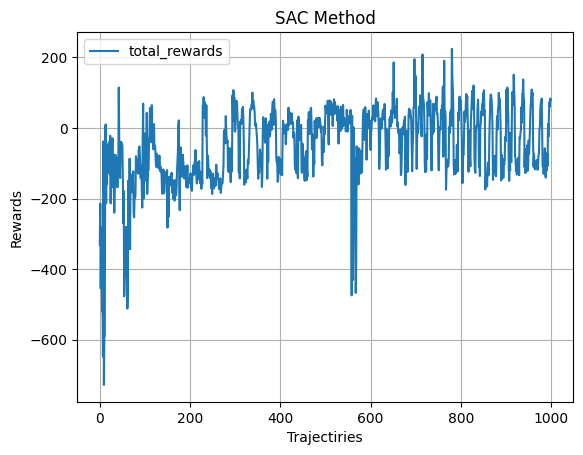

In [ ]:
episode_n = 1000
trajectory_len = 500

agent = SAC(state_dim, action_dim, gamma=0.99, alpha=1e-3, tau=1e-2,
            batch_size=500, pi_lr=1e-4, q_lr=1e-3)

total_rewards = main_sac(episode_n, trajectory_len)

print('Max total_reward', np.round(np.max(total_rewards), 2))
plt.plot(total_rewards, label='total_rewards')
plt.title('SAC Method')
plt.xlabel('Trajectiries')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()

Max mean_total_reward 35.73


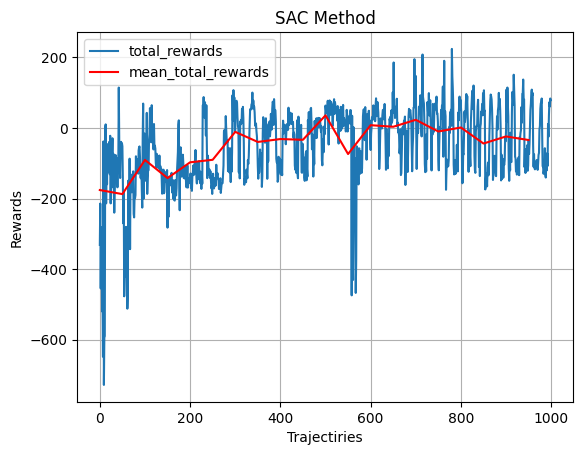

In [ ]:
mean_total_rewards = [np.mean(total_rewards[iter * episode_n // 20:
                      (iter + 1) * episode_n // 20]) for iter in range(20)]
print('Max mean_total_reward', np.round(np.max(mean_total_rewards), 2))
plt.plot(total_rewards, label='total_rewards')
plt.plot(range(0, episode_n, episode_n // 20),
         mean_total_rewards, label='mean_total_rewards', color='red')
plt.title('SAC Method')
plt.xlabel('Trajectiries')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()


## PPO Method

In [ ]:
class PPO(nn.Module):
    # Пространство действий непрерывное, многомерное

    def __init__(self, state_dim, action_dim, gamma=0.9, batch_size=128,
                 epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=5e-4):

        super().__init__()

        self.pi_model = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(),
                                      nn.Linear(128, 128), nn.ReLU(),
                                      nn.Linear(128, 2 * action_dim), nn.Tanh())

        self.v_model = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(),
                                     nn.Linear(128, 128), nn.ReLU(),
                                     nn.Linear(128, 1))

        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = epsilon
        self.epoch_n = epoch_n
        self.pi_optimizer = torch.optim.Adam(self.pi_model.parameters(), lr=pi_lr)
        self.v_optimizer = torch.optim.Adam(self.v_model.parameters(), lr=v_lr)

    def get_action(self, state):
        out = self.pi_model(torch.FloatTensor(state))
        mean = out[: action_dim]
        log_std = out[action_dim :]

        dist = Normal(mean, torch.exp(log_std))
        action = dist.sample()
        return action.detach().numpy().reshape(action_dim)

    def fit(self, states, actions, rewards, termins, truncs, new_states, option):

        states, actions, rewards, termins, truncs, new_states = map(np.array,
                      [states, actions, rewards, termins, truncs, new_states])
        rewards = rewards.reshape(-1, 1)
        termins = termins.reshape(-1, 1)
        truncs = truncs.reshape(-1, 1)

        returns = rewards.copy()
        for t in range(returns.shape[0] - 2, -1, -1):
            returns[t] += (1 - termins[t]) * (1 - truncs[t]) * self.gamma * returns[t + 1]

        states, actions, rewards, returns, new_states = map(torch.FloatTensor,
                          [states, actions, rewards, returns, new_states])

        out = self.pi_model(states).T
        mean = out[: action_dim].T
        log_std = out[action_dim :].T
        dist = Normal(mean, torch.exp(log_std))
        old_log_probs = dist.log_prob(actions).detach()

        for epoch in range(self.epoch_n):

            idxs = np.random.permutation(returns.shape[0])
            for i in range(0, returns.shape[0], self.batch_size):
                b_idxs = idxs[i: i + self.batch_size]
                b_states = states[b_idxs]
                b_actions = actions[b_idxs]
                b_rewards = rewards[b_idxs]
                b_returns = returns[b_idxs]
                b_new_states = new_states[b_idxs]
                b_old_log_probs = old_log_probs[b_idxs]

                if option == 0:
                    b_advantage = b_returns.detach() - self.v_model(b_states)
                elif option == 1:
                    b_advantage = b_rewards.detach() - self.v_model(b_states) \
                       + self.gamma * self.v_model(b_new_states).detach()
                else:
                    print('option is not found')

                b_out = self.pi_model(b_states).T
                b_mean = b_out[: action_dim].T
                b_log_std = b_out[action_dim :].T
                b_dist = Normal(b_mean, torch.exp(b_log_std))
                b_new_log_probs = b_dist.log_prob(b_actions)

                b_ratio = torch.exp(b_new_log_probs - b_old_log_probs)
                pi_loss_1 = b_ratio * b_advantage.detach()
                pi_loss_2 = torch.clamp(b_ratio, 1. - self.epsilon,  1. + self.epsilon) * b_advantage.detach()
                pi_loss = - torch.mean(torch.min(pi_loss_1, pi_loss_2))

                pi_loss.backward()
                self.pi_optimizer.step()
                self.pi_optimizer.zero_grad()

                v_loss = torch.mean(b_advantage ** 2)

                v_loss.backward()
                self.v_optimizer.step()
                self.v_optimizer.zero_grad()


In [ ]:
def main_ppo(option, episode_n, trajectory_n, trajectory_len):

    total_rewards = []

    for episode in range(episode_n):

        states, actions, rewards, termins, truncs, new_states = [], [], [], [], [], []

        for _ in range(trajectory_n):
            total_reward = 0

            state, _ = env.reset()
            for t in range(trajectory_len):
                states.append(state)

                action = agent.get_action(state)
                actions.append(action)

                new_state, reward, termin, trunc, _ = env.step(
                    env.action_space.low + action * (
                        env.action_space.high - env.action_space.low))
                new_states.append(new_state)
                rewards.append(reward)
                termins.append(termin)
                truncs.append(trunc)

                total_reward += reward
                state = new_state

                if termin or trunc:
                    break

            total_rewards.append(total_reward)

        agent.fit(states, actions, rewards, termins, truncs, new_states, option)
    return total_rewards


Max mean_total_reward 168.86


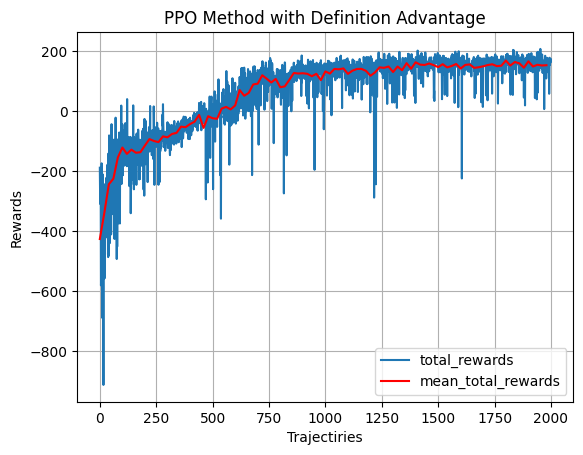

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

option = 0
episode_n = 100
trajectory_n = 20
trajectory_len = 500

agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
            epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)
mean_total_rewards = [np.mean(total_rewards[ind * trajectory_n:
                      (ind + 1) * trajectory_n]) for ind in range(episode_n)]

print('Max mean_total_reward', np.round(np.max(mean_total_rewards), 2))
plt.plot(total_rewards, label='total_rewards')
plt.plot(range(0, episode_n*trajectory_n, trajectory_n),
         mean_total_rewards, label='mean_total_rewards', color='red')

plt.title('PPO Method with Definition Advantage')
plt.xlabel('Trajectiries')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()

Max mean_total_reward 2.56


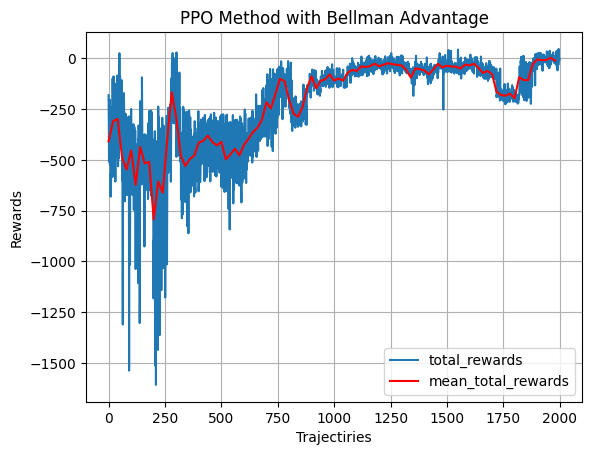

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

option = 1
episode_n = 100
trajectory_n = 20
trajectory_len = 500

agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
            epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)
mean_total_rewards = [np.mean(total_rewards[ind * trajectory_n:
                      (ind + 1) * trajectory_n]) for ind in range(episode_n)]

print('Max mean_total_reward', np.round(np.max(mean_total_rewards), 2))
plt.plot(total_rewards, label='total_rewards')
plt.plot(range(0, episode_n*trajectory_n, trajectory_n),
         mean_total_rewards, label='mean_total_rewards', color='red')

plt.title('PPO Method with Bellman Advantage')
plt.xlabel('Trajectiries')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()

## Modified DQN Method

In [ ]:
class Qfun(nn.Module):
    def __init__(self, state_dim, action_n):
        super().__init__()
        self.linear_1 = nn.Linear(state_dim, 128)
        self.linear_2 = nn.Linear(128, 128)
        self.linear_3 = nn.Linear(128, action_n)
        self.activation = nn.ReLU()

    def forward(self, states):
        hidden = self.linear_1(states)
        hidden = self.activation(hidden)
        hidden = self.linear_2(hidden)
        hidden = self.activation(hidden)
        actions = self.linear_3(hidden)

        return actions

In [ ]:
class Modified_DQN:
    # Пространство действий дискретное

    def __init__(self, state_dim, action_n, gamma=0.99, lr=1e-3,
                 batch_size=64, epsilon_decrease=0.01, epilon_min=0.01):
        self.state_dim = state_dim
        self.action_n = action_n
        self.q_fun_cur = Qfun(self.state_dim, self.action_n)
        self.q_fun_new = Qfun(self.state_dim, self.action_n)
        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = 1
        self.epsilon_decrease = epsilon_decrease
        self.epilon_min = epilon_min
        self.memory = []
        self.optimazer = torch.optim.Adam(self.q_fun_cur.parameters(), lr=lr)

        for param in self.q_fun_new.parameters():
            param.requires_grad = False              # not train

    def get_action(self, state):
        q_values = self.q_fun_cur(torch.FloatTensor(state))
        argmax_action = torch.argmax(q_values)
        probs = self.epsilon * np.ones(self.action_n) / self.action_n
        probs[argmax_action] += 1 - self.epsilon
        action = np.random.choice(np.arange(self.action_n), p=probs)
        return action

    def fit(self, state, action, reward, termin, trunc, next_state, method):
        self.memory.append([state, action, reward,
                            int(termin), int(trunc), next_state])

        if len(self.memory) > self.batch_size:
            batch = random.sample(self.memory, self.batch_size)
            states, actions, rewards, termins, truncs, next_states \
                             = map(np.array, list(zip(*batch)))
            states, actions, rewards, termins, truncs, next_states = map(
                             torch.tensor, [states, actions, rewards,
                                            termins, truncs, next_states])

            if method == 0:
                # DQN Method
                targets = rewards + self.gamma * (1 - termins) * (1 - truncs) \
                        * torch.max(self.q_fun_cur(next_states), dim=1).values
            elif method == 1 or method == 2:
                # Hard or Soft Target
                targets = rewards + self.gamma * (1 - termins) * (1 - truncs) \
                        * torch.max(self.q_fun_new(next_states), dim=1).values
            elif method == 3:
                # Double DQN
                targets = rewards + self.gamma * (1 - termins) * (1 - truncs) \
                 * self.q_fun_cur(next_states)[torch.arange(self.batch_size),
                        torch.argmax(self.q_fun_new(next_states), dim=1)]
            else:
                print('Method is not found')

            q_values = self.q_fun_cur(states)[torch.arange(self.batch_size), actions]

            loss = torch.mean((q_values - targets.detach()) ** 2)
            loss.backward()
            self.optimazer.step()
            self.optimazer.zero_grad()

            if self.epsilon > self.epilon_min:
                self.epsilon -= self.epsilon_decrease

    def main_mod_dqn(self, env, episode_n, t_max, tau, method):
        total_rewards = []
        for episode in range(episode_n):
            total_reward = 0

            if method == 1:
                if (episode_n % 50 == 0):
                    for new_par, cur_par in zip(self.q_fun_new.parameters(),
                                                self.q_fun_cur.parameters()):
                        new_par.data.copy_(cur_par.data)

            state, _ = env.reset()
            for t in range(t_max):

                discr_action = self.get_action(state)
                action = discr2contin(discr_action)

                next_state, reward, termin, trunc, _ = env.step(action)
                total_reward += reward
                self.fit(state, discr_action, reward, termin, trunc, next_state, method)
                state = next_state

                if method == 2 or method == 3:
                    for new_par, cur_par in zip(self.q_fun_new.parameters(),
                                                self.q_fun_cur.parameters()):
                        new_par.data.copy_(tau * cur_par.data + (1 - tau) * new_par.data)
                if termin or trunc:
                    break

            total_rewards.append(total_reward)
      #      print(episode, total_reward)
        return total_rewards


Дискретизация

In [ ]:
action_low = env.action_space.low
action_high = env.action_space.high
print('action_low =', action_low)
print('action_high =', action_high)

div = 21   # число точек разбиения каждой координаты
action_n = div ** action_dim
print('action_n =', action_n)

action_low = [-1. -1.]
action_high = [1. 1.]
action_n = 441


In [ ]:
def discr2contin(d_action):
    step = (action_high - action_low) / (div - 1)
    action = action_low.copy()
    if action_dim == 1:
        action += d_action * step
    elif action_dim == 2:
        action[0] += d_action % div * step[0]
        action[1] += d_action // div * step[1]
    else:
        print('In other time')

    return action

Max mean_total_reward 185.19


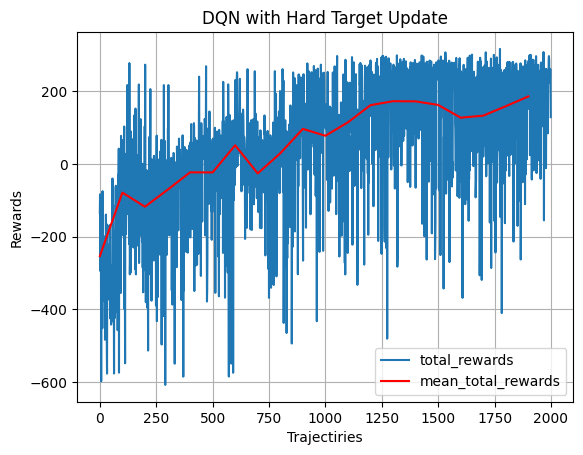

In [ ]:
# Modified DQN Methods
#     method = 1 means DQN with Hard Target Update
#     method = 2 means DQN with Soft Target Update

episode_n = 2000
t_max = 500
tau = 0.01
method = 1

agent = Modified_DQN(state_dim, action_n, gamma=0.99, lr=1e-4,
                     batch_size=500, epsilon_decrease=0.01, epilon_min=0.01)

total_rewards = agent.main_mod_dqn(env, episode_n, t_max, tau, method)
mean_total_rewards = [np.mean(total_rewards[iter * episode_n // 20:
                      (iter + 1) * episode_n // 20]) for iter in range(20)]

print('Max mean_total_reward', np.round(np.max(mean_total_rewards), 2))
plt.plot(total_rewards, label='total_rewards')
plt.plot(range(0, episode_n, episode_n // 20),
         mean_total_rewards, label='mean_total_rewards', color='red')
plt.title('DQN with Hard Target Update')
plt.xlabel('Trajectiries')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()


Max mean_total_reward 94.78


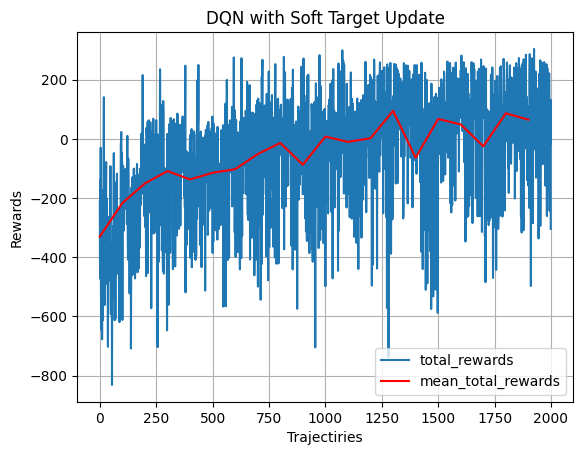

In [ ]:
# Modified DQN Methods
#     method = 1 means DQN with Hard Target Update
#     method = 2 means DQN with Soft Target Update

episode_n = 2000
t_max = 500
tau = 0.01
method = 2

agent = Modified_DQN(state_dim, action_n, gamma=0.99, lr=1e-4,
                     batch_size=500, epsilon_decrease=0.01, epilon_min=0.01)

total_rewards = agent.main_mod_dqn(env, episode_n, t_max, tau, method)
mean_total_rewards = [np.mean(total_rewards[iter * episode_n // 20:
                      (iter + 1) * episode_n // 20]) for iter in range(20)]

print('Max mean_total_reward', np.round(np.max(mean_total_rewards), 2))
plt.plot(total_rewards, label='total_rewards')
plt.plot(range(0, episode_n, episode_n // 20),
         mean_total_rewards, label='mean_total_rewards', color='red')
plt.title('DQN with Soft Target Update')
plt.xlabel('Trajectiries')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()


## Cross Entropy Method

In [8]:
class CEM_Contin(nn.Module):
#   Пространство действий непрерывное, многомерное

    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.state_dim = state_dim
        self.action_dim = action_dim

        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Tanh()
        )

    def forward(self, input):
        return self.network(input)


def cross_entropy_contin(env, agent, optimizer, loss_fun, iteration_n=20,
                         trajectory_n=500, trajectory_len=500, q_param=0.7):

    total_rewards = []

    for iteration in range(iteration_n):

        eps = (iteration_n - iteration) / iteration_n

        #policy evaluation
        all_states, all_actions, all_rewards = [], [], []
        for k in range(trajectory_n):
            states, actions, total_reward = get_trajectory_contin(
                                             env, agent, eps, trajectory_len)
            all_states.append(states)
            all_actions.append(actions)
            all_rewards.append(total_reward)
        total_rewards.extend(all_rewards)

   #     print('iteration:', iteration,
   #           'mean total reward:', np.mean(all_rewards))

        #policy improvement
        elite_states, elite_actions = select_elites(all_states, all_actions,
                                                    all_rewards, q_param)
        if len(elite_states) > 0:
            elite_states = np.array(elite_states)
            elite_actions = np.array(elite_actions)
            pred_actions = agent(torch.FloatTensor(elite_states))

            loss = loss_fun(pred_actions, torch.FloatTensor(elite_actions))
     #       print('\t\tloss:', loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    return total_rewards


def get_trajectory_contin(env, agent, eps, trajectory_len=1000):

    states, actions = [], []
    total_reward = 0.0

    state, _ = env.reset()

    for _ in range(trajectory_len):

        logit = agent(torch.FloatTensor(state))
        action = logit.detach().numpy()
        action += np.random.normal(0.0, eps, action_dim)
        action = np.clip(action, action_low, action_high)
        new_state, reward, terminated, truncated, _ = env.step(action)

        states.append(state)
        actions.append(action)
        total_reward += reward

        state = new_state
        if terminated or truncated:
            break

    return states, actions, total_reward


def select_elites(all_states, all_actions, all_rewards, q_param):
    quantile = np.quantile(all_rewards, q_param)
    elite_states = []
    elite_actions = []
    for i in range(len(all_rewards)):
        if all_rewards[i] > quantile:
            elite_states.extend(all_states[i])
            elite_actions.extend(all_actions[i])
    return elite_states, elite_actions


Max mean_total_reward 35.17


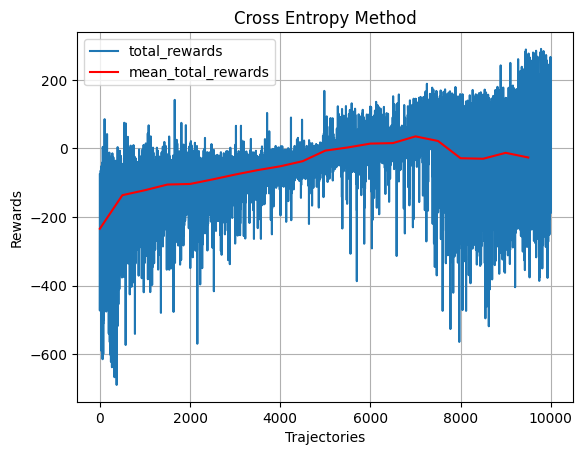

In [12]:
# CROSS ENTROPY METHOD

agent = CEM_Contin(state_dim, action_dim)
optimizer = torch.optim.Adam(agent.parameters(), lr=1e-2)
loss_fun = nn.MSELoss()
total_rewards = cross_entropy_contin(env, agent, optimizer, loss_fun,
                                     iteration_n=100, trajectory_n=100,
                                     trajectory_len=500, q_param=0.5)
episode_n = len(total_rewards)
mean_total_rewards = [np.mean(total_rewards[iter * episode_n // 20:
                      (iter + 1) * episode_n // 20]) for iter in range(20)]

print('Max mean_total_reward', np.round(np.max(mean_total_rewards), 2))
plt.plot(total_rewards, label='total_rewards')
plt.plot(range(0, episode_n, episode_n // 20),
         mean_total_rewards, label='mean_total_rewards', color='red')
plt.title('Cross Entropy Method')
plt.xlabel('Trajectories')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()
